<a href="https://colab.research.google.com/github/jorge-reynam/Reporte-de-atenciones/blob/main/Reporte_de_usuarios_SECTEI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reporte general de usuarios

### Importar las librerías para trabajar

In [193]:
#Importar librerías

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


### Cargar los datos de Google Sheets

In [194]:
#Hacer una función que lea la hoja de Google Sheets

def read_google_sheet(url, sheet_name):
    try:
        sheet_id = url.split("/d/")[1].split("/")[0]
        csv_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"
        df = pd.read_csv(csv_url)
        return df
    except Exception as e:
        print(f"Error al leer la hoja: {e}")
        return None


In [195]:
#Leer los datos desde el Google Sheets

url = "https://docs.google.com/spreadsheets/d/11UO33BWLkyARPpsn0QU7EdiaLitfsuN2/edit?usp=sharing&ouid=116787326570682110375&rtpof=true&sd=true"

df_atenciones = read_google_sheet(url, "Atenciones")

### Análisis Exploratorio de Datos

In [196]:
# AUDITORÍA DE CALIDAD (Data Health)
print("RESUMEN DE CALIDAD")
print(f"Registros totales: {len(df_atenciones):,}")
print(f"Valores nulos por columna:\n{df_atenciones.isnull().sum()}")
print(f"Duplicados exactos detectados: {df_atenciones.duplicated().sum()}")

RESUMEN DE CALIDAD
Registros totales: 51,000
Valores nulos por columna:
Fecha                  0
Folio                  0
Nombre                 0
Actividad           1553
Sexo                3014
Observaciones      10056
Tipo de Usuario        0
dtype: int64
Duplicados exactos detectados: 525


In [197]:
# LIMPIEZA DE DATOS (Data Wrangling)
# Eliminar duplicados
df_atenciones = df_atenciones.drop_duplicates()

# Normalizar nombres de Centros (Quitar espacios y corregir mayúsculas)
df_atenciones['Nombre'] = df_atenciones['Nombre'].str.strip().str.title()

# Tratar Nulos (Llenar con 'No especificado' para no perder la fila)
df_atenciones['Sexo'] = df_atenciones['Sexo'].fillna('No especificado')
df_atenciones['Actividad'] = df_atenciones['Actividad'].fillna('Sin Registro')

# Filtrar Outliers (El error de carga del 15 de Octubre)
# Identificamos el pico y lo removemos para la tendencia
fecha_error = pd.to_datetime('2025-10-15').date()
df_atenciones = df_atenciones[df_atenciones['Fecha'] != fecha_error]


### Atenciones diarias. Periodo 2025

In [198]:
#Función que devuelve las atenciones diarias

def daily_appointments(df):
    # Copia y limpieza del df
    df_processed = df.copy()
    df_processed['Fecha'] = pd.to_datetime(df_processed['Fecha'])

    # Filtrar solo para el año 2025
    df_processed = df_processed[(df_processed['Fecha'] >= '2025-01-01') & (df_processed['Fecha'] <= '2025-12-31')]

    # Agrupar por día (Serie temporal completa)
    daily_data = df_processed.groupby('Fecha').size()

    # Calcular media móvil
    # Usamos min_periods=1 para que empiece a graficar desde el primer día
    daily_rolling = daily_data.rolling(window=7, min_periods=1).mean()

    # Graficar
    plt.figure(figsize=(20, 8)) # Reduje un poco el ancho para que sea más manejable

    # Convertimos el índice a string para el barplot para que Seaborn lo trate como categorías
    fechas_str = daily_data.index.strftime('%Y-%m-%d')

    # Graficar barras
    sns.barplot(x=fechas_str, y=daily_data.values, color='#8b0000', label='Atenciones Diarias', alpha=0.6)

    # Graficar línea (USANDO EL MISMO EJE X QUE LAS BARRAS)
    sns.lineplot(x=fechas_str, y=daily_rolling.values, color='blue', label='Media Móvil (7 días)', linewidth=3)

    # Mostrar solo algunas etiquetas en X para que no se sature
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(20))

    plt.title('Atenciones Diarias (2025) - Corrección de Tendencia')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

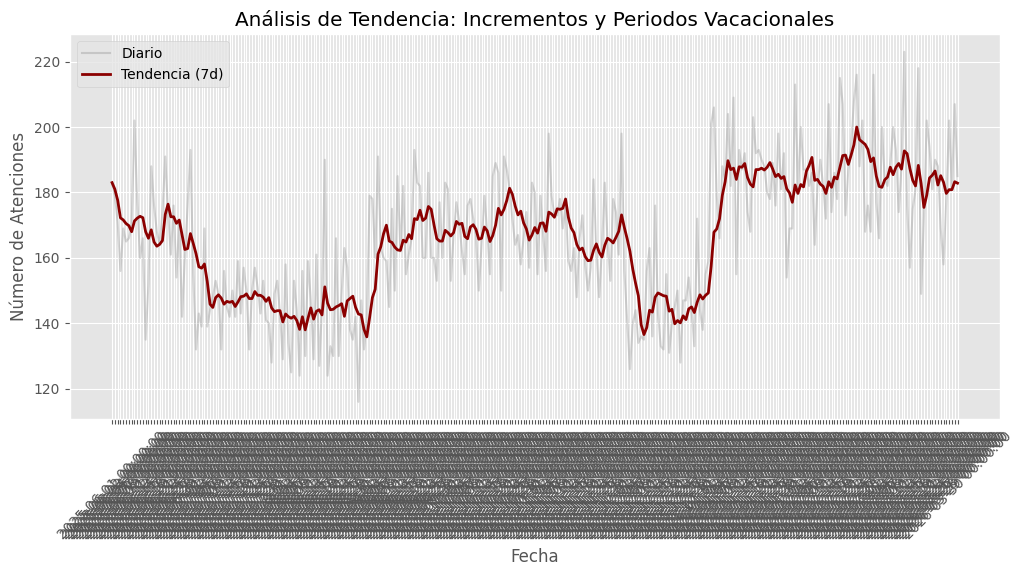

In [199]:
# VISUALIZACIÓN
plt.style.use('ggplot')

# FIGURA 1: Tendencia temporal con media móvil
plt.figure(figsize=(12, 5))
daily_counts = df_atenciones.groupby('Fecha').size()
rolling_7d = daily_counts.rolling(window=7, min_periods=1).mean()

sns.lineplot(x=daily_counts.index, y=daily_counts.values, color='gray', alpha=0.3, label='Diario')
sns.lineplot(x=rolling_7d.index, y=rolling_7d.values, color='#8b0000', linewidth=2, label='Tendencia (7d)')

plt.title('Análisis de Tendencia: Incrementos y Periodos Vacacionales')
plt.ylabel('Número de Atenciones')
plt.legend()
plt.xticks(rotation=45)
plt.show()


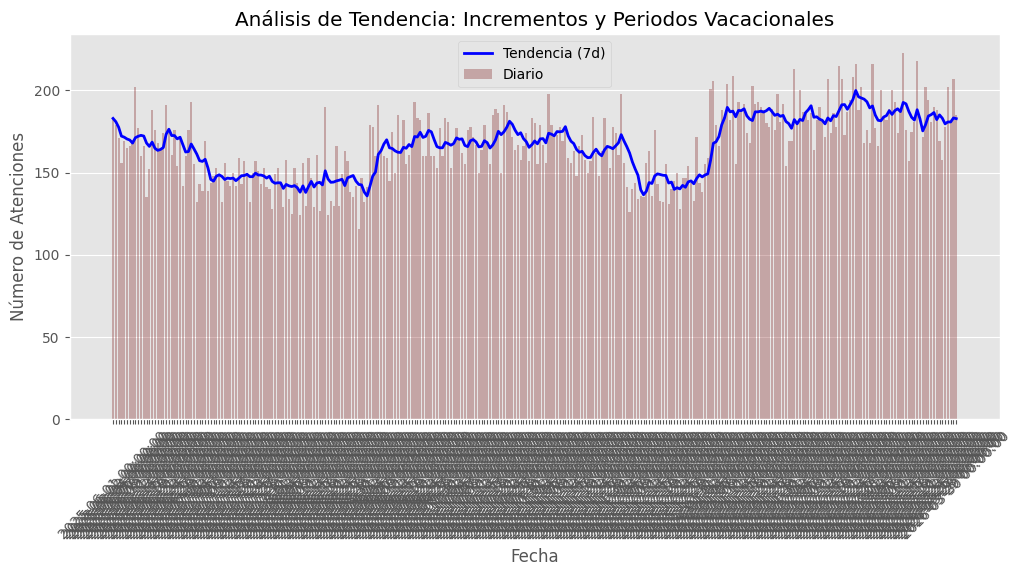

In [200]:
# VISUALIZACIÓN

# FIGURA 1: Tendencia temporal con media móvil
plt.figure(figsize=(12, 5))
daily_counts = df_atenciones.groupby('Fecha').size()
rolling_7d = daily_counts.rolling(window=7, min_periods=1).mean()

sns.barplot(x=daily_counts.index, y=daily_counts.values, color='#8b0000', alpha=0.3, label='Diario')
sns.lineplot(x=rolling_7d.index, y=rolling_7d.values, color='blue', linewidth=2, label='Tendencia (7d)')

plt.title('Análisis de Tendencia: Incrementos y Periodos Vacacionales')
plt.ylabel('Número de Atenciones')
plt.legend()
plt.xticks(rotation=45)
plt.show()


/tmp/ipykernel_5771/3918018223.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_atenciones, y='Nombre', order=order, palette='viridis')


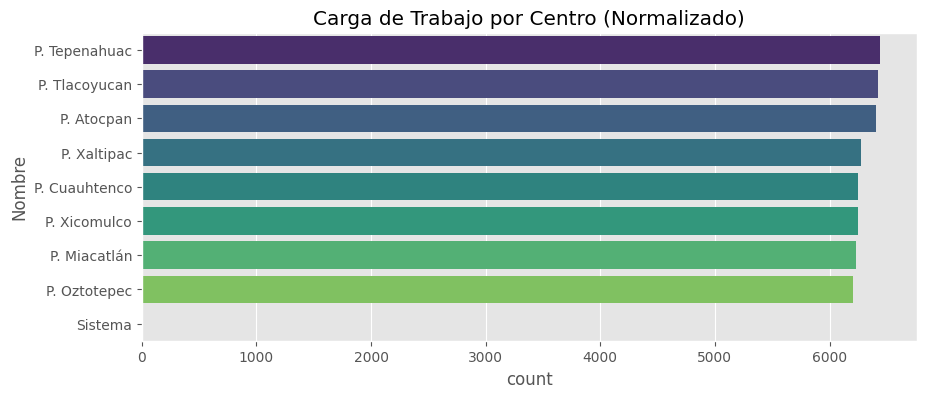

In [201]:
# FIGURA 2: Comparativa de Centros de Trabajo (Top 5)
plt.figure(figsize=(10, 4))
order = df_atenciones['Nombre'].value_counts().index
sns.countplot(data=df_atenciones, y='Nombre', order=order, palette='viridis')
plt.title('Carga de Trabajo por Centro (Normalizado)')
plt.show()

/tmp/ipykernel_5771/3875230605.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_atenciones, x='Tipo de Usuario', palette='Set2')


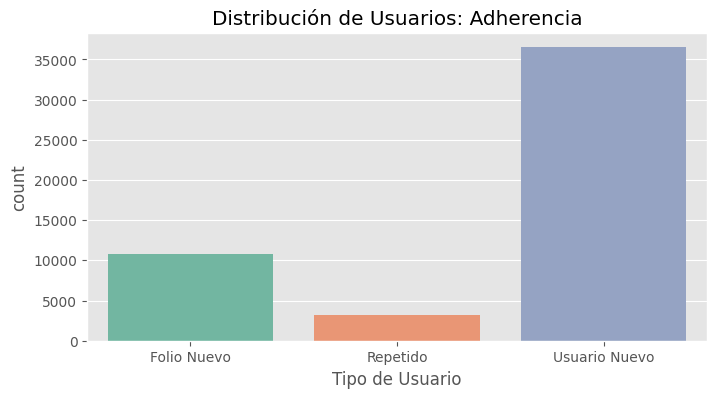

In [202]:
# FIGURA 3: Composición de Usuarios (Adherencia)
plt.figure(figsize=(8, 4))
sns.countplot(data=df_atenciones, x='Tipo de Usuario', palette='Set2')
plt.title('Distribución de Usuarios: Adherencia')
plt.show()


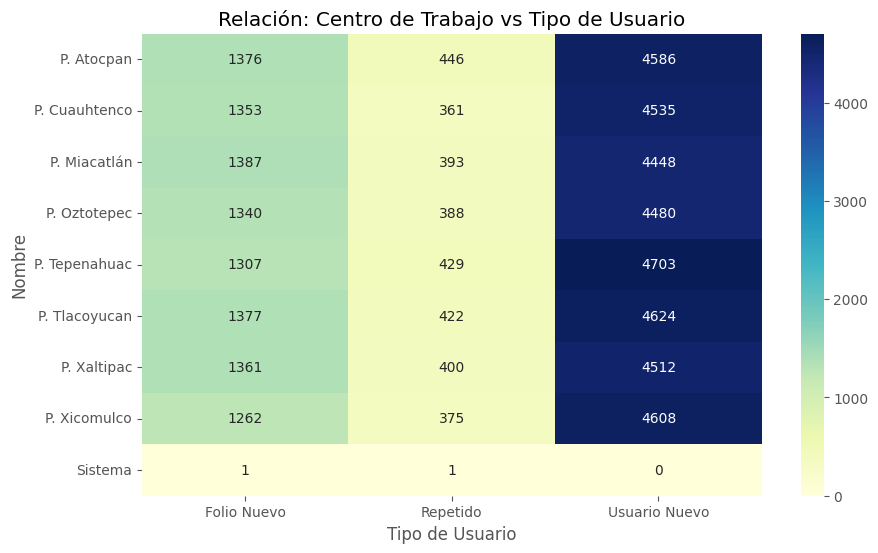

In [203]:
# ANÁLISIS MULTIVARIANTE (Heatmap)
# ¿Qué actividades se hacen en qué centros?
df_atenciones = df_atenciones.pivot_table(index='Nombre', columns='Tipo de Usuario', aggfunc='size', fill_value=0)

plt.figure(figsize=(10, 6))
sns.heatmap(df_atenciones, annot=True, fmt="d", cmap="YlGnBu")
plt.title('Relación: Centro de Trabajo vs Tipo de Usuario')
plt.show()

In [204]:
#Función que devuelve las atenciones por mes

def monthly_appointments(df):
  # Crear una copia del DataFrame para evitar modificar el original
  df_processed = df.copy()

  # Convertir los strings a formato fecha si no lo están ya
  if not pd.api.types.is_datetime64_any_dtype(df_processed['Fecha']):
    df_processed['Fecha'] = df_processed['Fecha'].apply(lambda x: pd.to_datetime(x, format='%Y-%m-%d'))

  #Filtrar solo datos de 2025
  df_processed = df_processed[(df_processed['Fecha'] >= '2025-01-01') & (df_processed['Fecha'] <= '2025-12-31')]

  #Agrupar las atenciones por mes
  monthly_appointments_df = df_processed.groupby(pd.Grouper(key='Fecha', freq='ME')).size()

  #Graficar los folios por día
  plt.figure(figsize=(6, 3))
  sns.barplot(x=monthly_appointments_df.index.strftime('%Y-%m'), y=monthly_appointments_df.values, color='#8b0000', label='Atenciones Mensuales')
  plt.title('Atenciones mensuales de 2025')
  plt.xlabel('Fecha (Mes)')
  plt.ylabel('Número de atenciones')
  plt.xticks(rotation=45)
  plt.legend()
  plt.tight_layout()
  plt.show()